# Классификация: CC50 > медианы

Цель — построить бинарную модель, которая определяет, превышает ли показатель заданный порог. Используются LogisticRegression, SVC, RandomForest, GradientBoosting и baseline DummyClassifier.


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR, SVC

RANDOM_STATE = 42
TARGET_COLUMNS = ['IC50, mM', 'CC50, mM', 'SI']
DATA_PATH = Path('../data/drug_activity.csv')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)


def load_data():
    df = pd.read_csv(DATA_PATH)
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])
    return df


def split_features_target(df, target):
    # Важно: удаляем все три целевые колонки, чтобы не было утечки данных.
    # SI рассчитывается через IC50 и CC50, поэтому их нельзя использовать как признаки.
    X = df.drop(columns=[c for c in TARGET_COLUMNS if c in df.columns])
    y = df[target]
    return X, y


def make_binary_target(y, mode):
    if mode == 'median':
        threshold = y.median()
    elif mode == 'si_gt_8':
        threshold = 8.0
    else:
        raise ValueError(mode)
    return (y > threshold).astype(int), threshold


def preprocessing_steps(scale=False):
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('variance', VarianceThreshold())
    ]
    if scale:
        steps.append(('scaler', StandardScaler()))
    return steps


def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2': r2_score(y_true, y_pred),
    }


def classification_metrics(y_true, y_pred, y_proba=None):
    res = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None and len(np.unique(y_true)) == 2:
        res['ROC_AUC'] = roc_auc_score(y_true, y_proba)
    return res


def classification_models():
    return {
        'DummyMostFrequent': Pipeline(preprocessing_steps(False) + [
            ('model', DummyClassifier(strategy='most_frequent'))
        ]),
        'LogisticRegression': Pipeline(preprocessing_steps(True) + [
            ('model', LogisticRegression(
                max_iter=1500,
                class_weight='balanced',
                random_state=RANDOM_STATE
            ))
        ]),
        'SVC_RBF': Pipeline(preprocessing_steps(True) + [
            ('model', SVC(
                C=3.0,
                gamma='scale',
                probability=True,
                class_weight='balanced',
                random_state=RANDOM_STATE
            ))
        ]),
        'RandomForest': Pipeline(preprocessing_steps(False) + [
            ('model', RandomForestClassifier(
                n_estimators=80,
                max_features='sqrt',
                class_weight='balanced',
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),
        'GradientBoosting': Pipeline(preprocessing_steps(False) + [
            ('model', GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.05,
                max_depth=2,
                random_state=RANDOM_STATE
            ))
        ]),
    }


def tune_gradient_boosting_classification(X_train, y_train, X_valid, y_valid):
    params = [
        {'n_estimators': 60, 'learning_rate': 0.05, 'max_depth': 1},
        {'n_estimators': 80, 'learning_rate': 0.05, 'max_depth': 2},
        {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2},
        {'n_estimators': 80, 'learning_rate': 0.08, 'max_depth': 2},
    ]
    rows = []
    best_model = None
    best_f1 = -1
    for p in params:
        model = Pipeline(preprocessing_steps(False) + [
            ('model', GradientBoostingClassifier(random_state=RANDOM_STATE, **p))
        ])
        model.fit(X_train, y_train)
        pred = model.predict(X_valid)
        metrics = classification_metrics(y_valid, pred)
        row = {**p, **metrics}
        rows.append(row)
        if metrics['F1'] > best_f1:
            best_f1 = metrics['F1']
            best_model = model
    return best_model, pd.DataFrame(rows).sort_values('F1', ascending=False)


In [2]:
df = load_data()
X, y_raw = split_features_target(df, 'CC50, mM')
y, threshold = make_binary_target(y_raw, 'median')
print('Задача:', 'CC50 > медианы')
print('Порог:', threshold)
print('Размер X:', X.shape)
print('Баланс классов:')
display(y.value_counts(normalize=True).rename('share'))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
print('Train:', X_train.shape, 'Test:', X_test.shape)


Задача: CC50 > медианы
Порог: 411.0393423
Размер X: (1001, 210)
Баланс классов:


CC50, mM
0    0.501499
1    0.498501
Name: share, dtype: float64

Train: (800, 210) Test: (201, 210)


## Сравнение базовых моделей


In [3]:
rows = []
for name, model in classification_models().items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = None
    try:
        proba = model.predict_proba(X_test)[:, 1]
    except Exception:
        pass
    row = {'model': name}
    row.update(classification_metrics(y_test, pred, proba))
    rows.append(row)

metrics_df = pd.DataFrame(rows).sort_values('F1', ascending=False)
display(metrics_df)


,model,Accuracy,Precision,Recall,F1,ROC_AUC
3,RandomForest,0.741294,0.718182,0.79,0.752381,0.842079
2,SVC_RBF,0.731343,0.694915,0.82,0.752294,0.832673
1,LogisticRegression,0.731343,0.709091,0.78,0.742857,0.833465
4,GradientBoosting,0.701493,0.678571,0.76,0.716981,0.823416
0,DummyMostFrequent,0.502488,0.000000,0.00,0.000000,0.500000


## Подбор гиперпараметров GradientBoostingClassifier


In [4]:
X_fit, X_valid, y_fit, y_valid = train_test_split(
    X_train, y_train,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train
)

best_tuned_model, tuning_df = tune_gradient_boosting_classification(
    X_fit, y_fit, X_valid, y_valid
)

display(tuning_df)


,n_estimators,learning_rate,max_depth,Accuracy,Precision,Recall,F1
3,80,0.08,2,0.755,0.721739,0.83,0.772093
1,80,0.05,2,0.745,0.713043,0.82,0.762791
2,100,0.05,2,0.740,0.706897,0.82,0.759259
0,60,0.05,1,0.715,0.683761,0.80,0.737327


## Финальное сравнение


In [5]:
best_tuned_model.fit(X_train, y_train)
pred = best_tuned_model.predict(X_test)
proba = best_tuned_model.predict_proba(X_test)[:, 1]

tuned_row = {'model': 'Tuned_GradientBoosting'}
tuned_row.update(classification_metrics(y_test, pred, proba))

final_metrics = pd.concat([
    metrics_df,
    pd.DataFrame([tuned_row])
], ignore_index=True).sort_values('F1', ascending=False)

display(final_metrics)

final_metrics.to_csv(RESULTS_DIR / 'classification_cc50_gt_median_metrics.csv', index=False)
tuning_df.to_csv(RESULTS_DIR / 'classification_cc50_gt_median_tuning.csv', index=False)


,model,Accuracy,Precision,Recall,F1,ROC_AUC
0,RandomForest,0.741294,0.718182,0.79,0.752381,0.842079
1,SVC_RBF,0.731343,0.694915,0.82,0.752294,0.832673
2,LogisticRegression,0.731343,0.709091,0.78,0.742857,0.833465
3,GradientBoosting,0.701493,0.678571,0.76,0.716981,0.823416
5,Tuned_GradientBoosting,0.701493,0.678571,0.76,0.716981,0.829356
4,DummyMostFrequent,0.502488,0.000000,0.00,0.000000,0.500000


## Матрица ошибок для настроенного бустинга


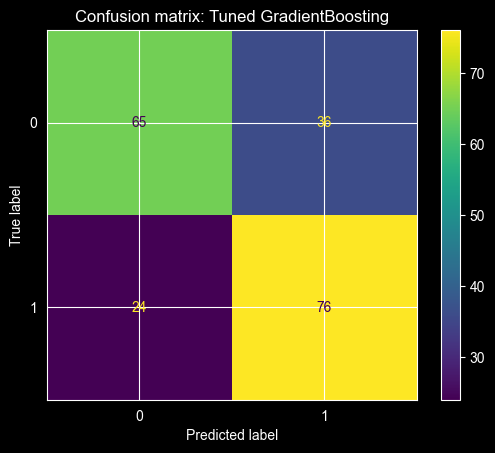

In [6]:
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion matrix: Tuned GradientBoosting')
plt.show()


## Вывод по задаче CC50 > медианы

Для бинарной классификации важны не только accuracy, но и F1, precision и recall. Финальная модель выбирается по F1, так как эта метрика учитывает баланс между полнотой и точностью.
